In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt


sys.path.append('../')


<>:100: SyntaxWarning: invalid escape sequence '\c'
<>:100: SyntaxWarning: invalid escape sequence '\c'
<>:100: SyntaxWarning: invalid escape sequence '\c'
<>:100: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_340467/2831711251.py:100: SyntaxWarning: invalid escape sequence '\c'
  label=f'Empirical Fit: $d_n = d_x \cdot ({a_fit:.2f} \cdot N^{{{b_fit:.2f}}})$')
/tmp/ipykernel_340467/2831711251.py:100: SyntaxWarning: invalid escape sequence '\c'
  label=f'Empirical Fit: $d_n = d_x \cdot ({a_fit:.2f} \cdot N^{{{b_fit:.2f}}})$')


Running grid search for d_x = 2...
  -> Fit successful for d_x=2: d_n = d_x * (2.606 * N^0.624)
Running grid search for d_x = 3...
  -> Fit successful for d_x=3: d_n = d_x * (1.356 * N^0.515)
Running grid search for d_x = 5...
  -> Fit successful for d_x=5: d_n = d_x * (0.914 * N^0.358)
Running grid search for d_x = 10...
  -> Fit successful for d_x=10: d_n = d_x * (0.453 * N^0.275)
Running grid search for d_x = 25...
  -> Fit successful for d_x=25: d_n = d_x * (0.179 * N^0.229)
Running grid search for d_x = 50...
  -> Fit successful for d_x=50: d_n = d_x * (0.095 * N^0.201)


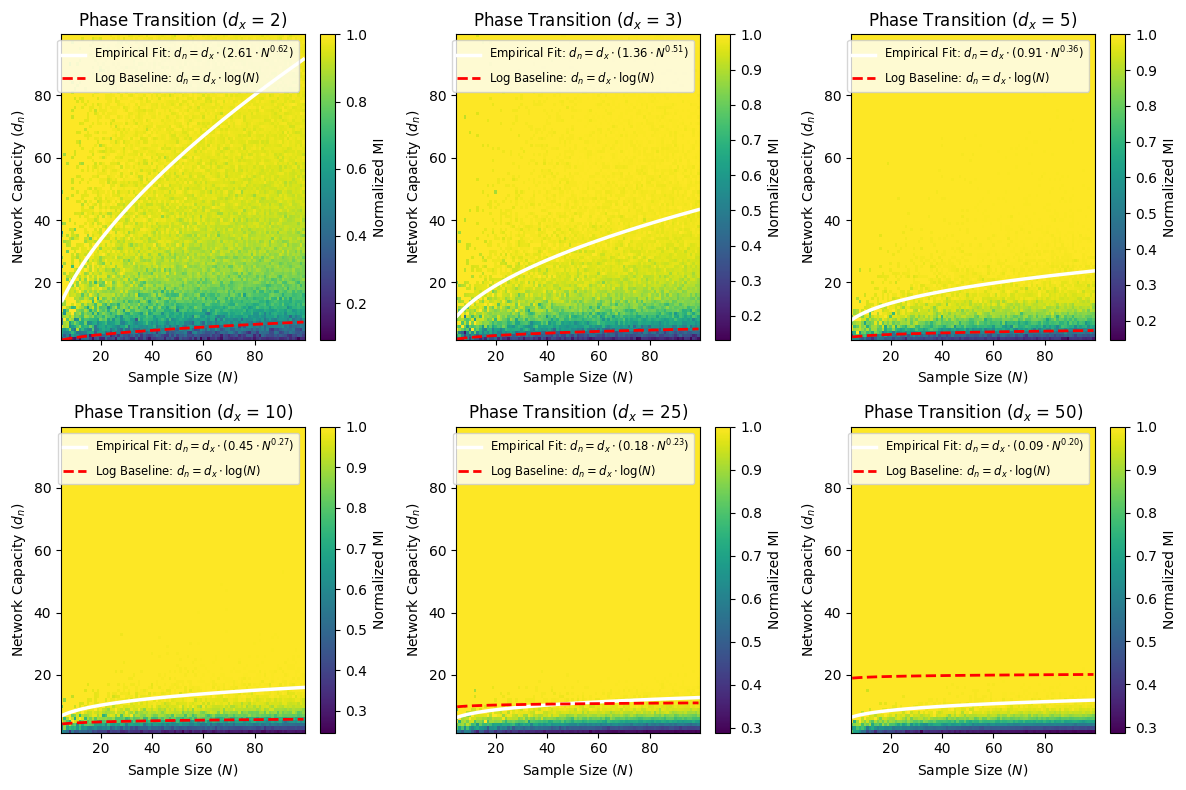

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
from scipy.optimize import curve_fit  # Added for curve fitting

def get_normalized_mi(X, model):
    """
    Passes data X through a single-layer network to get activation patterns,
    and calculates the normalized Mutual Information I(X;T) / H(X).
    """
    with torch.no_grad():
        # Get pre-activations: Z = XW + b
        Z = model(X)
        # Binarize to get discrete activation patterns (1 if active, 0 if inactive)
        T = (Z > 0).int().numpy()
        
    # Find unique activation patterns (bins) and how many points fall in each
    unique_patterns, counts = np.unique(T, axis=0, return_counts=True)
    
    # Calculate empirical entropy of the bins H(T)
    probabilities = counts / np.sum(counts)
    H_T = entropy(probabilities, base=2)
    
    # Max possible entropy is log2(N) (when every point is in its own bin)
    N = X.shape[0]
    H_X = np.log2(N)
    
    # Return Normalized MI
    return H_T / H_X if H_X > 0 else 0.0

def power_law(N, a, b):
    """Function to fit: a * N^b"""
    return a * (N ** b)

def run_experiment_1(dx=2, ax=None):
    # 1. Define bounds for our grid search
    d_x = dx  # Fix input dimensionality
    N_values = np.arange(5, 100, 1)        # Number of samples N
    dn_values = np.arange(2, 100, 1)       # Network width (capacity) d_n
    
    # Matrix to store the Normalized MI for the heatmap
    mi_matrix = np.zeros((len(dn_values), len(N_values)))
    
    print(f"Running grid search for d_x = {d_x}...")
    
    # 2. Run the grid search
    for i, d_n in enumerate(dn_values):
        for j, N in enumerate(N_values):
            # Generate N random data points in d_x dimensions
            X = torch.randn(N, d_x)
            
            # Initialize a single CPWL layer (random weights)
            layer = nn.Linear(d_x, d_n)
            
            # Calculate MI
            mi_matrix[i, j] = get_normalized_mi(X, layer)
            
    # 3. Plotting the Heatmap
    X_mesh, Y_mesh = np.meshgrid(N_values, dn_values)
    
    cp = ax.pcolormesh(X_mesh, Y_mesh, mi_matrix, shading='auto', cmap='viridis')
    plt.colorbar(cp, ax=ax, label='Normalized MI')
    
    # 4. Find the "Cliff" and Fit the Curve
    threshold = 0.99  # Hitting 98% of max MI is our threshold for memorization
    cliff_N = []
    cliff_dn = []
    
    # Scan each column (each N) to find the first d_n that crosses the threshold
    for j, N in enumerate(N_values):
        mi_column = mi_matrix[:, j]
        cross_indices = np.where(mi_column >= threshold)[0]
        if len(cross_indices) > 0:
            cliff_N.append(N)
            cliff_dn.append(dn_values[cross_indices[0]])
            
    cliff_N = np.array(cliff_N)
    cliff_dn = np.array(cliff_dn)
    
    # Fit the curve if we found enough boundary points
    if len(cliff_N) > 3:
        # We assume d_n = d_x * (a * N^b), so we isolate the 'something'
        empirical_something = cliff_dn / d_x

        try:
            # Fit the power law to the empirical 'something'
            # p0 is the initial guess: [a=1.0, b=1/d_x] based on Zaslavsky's hints
            popt, _ = curve_fit(power_law, cliff_N, empirical_something, p0=[1.0, 1/d_x], maxfev=10000)
            a_fit, b_fit = popt
            
            # Generate the curve for plotting: d_n = d_x * (a * N^b)
            fit_dn = d_x * power_law(N_values, a_fit, b_fit)
            valid_fit_idx = fit_dn <= max(dn_values)
            
            # Plot the fitted curve
            ax.plot(N_values[valid_fit_idx], fit_dn[valid_fit_idx], 
                     color='white', linestyle='-', linewidth=2.5, 
                     label=f'Empirical Fit: $d_n = d_x \cdot ({a_fit:.2f} \cdot N^{{{b_fit:.2f}}})$')
            print(f"  -> Fit successful for d_x={d_x}: d_n = d_x * ({a_fit:.3f} * N^{b_fit:.3f})")
            
        except RuntimeError:
            print(f"  -> Curve fitting failed to converge for d_x={d_x}")
    else:
        print(f"  -> Not enough boundary points found to fit curve for d_x={d_x}. Consider increasing max d_n.")

    # 5. Plot the original log baseline hypothesis for comparison
    hypothesis_dn = d_x * (1/np.e * N_values ** (1/d_x))  # Using the form d_n = d_x * (N^(1/d_x) / e)
    valid_idx = hypothesis_dn <= max(dn_values)
    ax.plot(N_values[valid_idx], hypothesis_dn[valid_idx], 
             color='red', linestyle='--', linewidth=2, label=r'Log Baseline: $d_n = d_x \cdot \log(N)$')
    
    ax.set_title(f"Phase Transition ($d_x$ = {d_x})")
    ax.set_xlabel("Sample Size ($N$)")
    ax.set_ylabel("Network Capacity ($d_n$)")
    ax.legend(loc='upper right', fontsize='small')


if __name__ == "__main__":
    dx_values = [2, 3, 5, 10, 25, 50]  # Different input dimensions to test
    # Increased figsize slightly to accommodate 5 plots comfortably
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    
    for ax, dx in zip(axes, dx_values): 
        run_experiment_1(dx=dx, ax=ax)
        
    plt.tight_layout()
    plt.show()

# Memorization / Capacity

In [10]:
from src_experiment.paths import outputs
from src_experiment.estimate_quantities import ExperimentEvaluator

def get_mempath(neuron_config="333"):
    return outputs / f"exp_1_capacity/moons_{neuron_config}/moons_{neuron_config}.h5"

In [ ]:
# Define figure

# fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(8, 12))
n_samples = 10000
n_test = 10000 * 0.2
H = np.log2(n_samples)  # Max possible entropy for N samples


In [11]:
est1 = ExperimentEvaluator(get_mempath("333"))

Evaluating moons_333.h5...
  - Loading Epoch 0...
  - Loading Epoch 1...
  - Loading Epoch 2...
  - Loading Epoch 3...
  - Loading Epoch 4...
  - Loading Epoch 6...
  - Loading Epoch 8...
  - Loading Epoch 10...
  - Loading Epoch 20...
  - Loading Epoch 30...
  - Loading Epoch 40...
  - Loading Epoch 50...
  - Loading Epoch 60...
  - Loading Epoch 70...
  - Loading Epoch 80...
  - Loading Epoch 90...
  - Loading Epoch 100...
  - Loading Epoch 110...
  - Loading Epoch 120...
  - Loading Epoch 130...
  - Loading Epoch 140...
  - Loading Epoch 150...


In [25]:
experiment_names = {
    3: "333",
    5: "555",
    7: "777",
    9: "999",
    11: "11",
    15: "15",
    20: "20",
    25: "25",
    50: "50",
    75: "75",
    100: "100",
    150: "150",
    250: "250",
    500: "500",
}

In [38]:

def plot_experiment(experiment_key, axes):
    est = ExperimentEvaluator(get_mempath(experiment_names[experiment_key]))
    MI = est.estimates["Mutual Information"]
    epoch = MI["epoch"]

    for ax, layers in zip(axes, ["l1", "l2", "l3"]):
        
        line = ax.plot(epoch, MI[layers], marker='o')
        # ax.set_title(f"Mutual Information for Layers: {layers}")
        # ax.set_xlabel("Epoch")
        # ax.set_ylabel("Mutual Information")
    label = r"$d_n$ = " + str(experiment_key)
    return line, label

Evaluating moons_333.h5...
  - Loading Epoch 0...
  - Loading Epoch 1...
  - Loading Epoch 2...
  - Loading Epoch 3...
  - Loading Epoch 4...
  - Loading Epoch 6...
  - Loading Epoch 8...
  - Loading Epoch 10...
  - Loading Epoch 20...
  - Loading Epoch 30...
  - Loading Epoch 40...
  - Loading Epoch 50...
  - Loading Epoch 60...
  - Loading Epoch 70...
  - Loading Epoch 80...
  - Loading Epoch 90...
  - Loading Epoch 100...
  - Loading Epoch 110...
  - Loading Epoch 120...
  - Loading Epoch 130...
  - Loading Epoch 140...
  - Loading Epoch 150...
Evaluating moons_555.h5...
  - Loading Epoch 0...
  - Loading Epoch 1...
  - Loading Epoch 2...
  - Loading Epoch 3...
  - Loading Epoch 4...
  - Loading Epoch 6...
  - Loading Epoch 8...
  - Loading Epoch 10...
  - Loading Epoch 20...
  - Loading Epoch 30...
  - Loading Epoch 40...
  - Loading Epoch 50...
  - Loading Epoch 60...
  - Loading Epoch 70...
  - Loading Epoch 80...
  - Loading Epoch 90...
  - Loading Epoch 100...
  - Loading Epoch

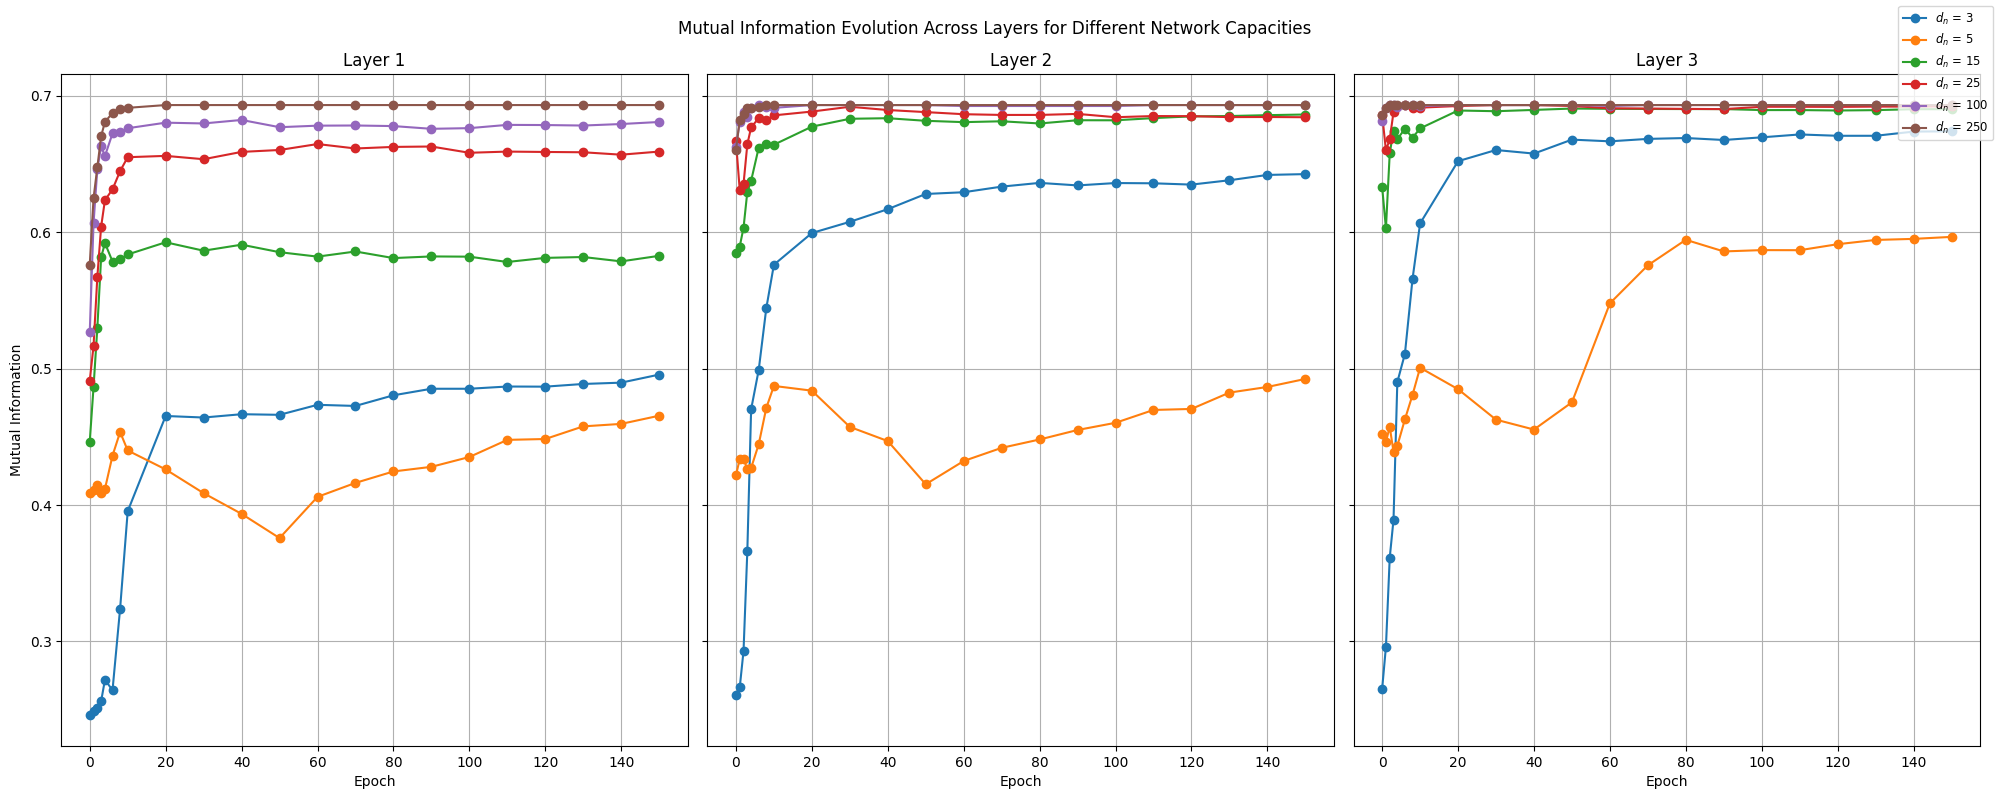

In [ ]:
fig, axes = plt.subplots(ncols=3, nrows=1, figsize=(20, 8), sharey=True)
axes[0].set_title("Layer 1")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mutual Information")
axes[1].set_title("Layer 2")
axes[1].set_xlabel("Epoch")
axes[2].set_title("Layer 3")
axes[2].set_xlabel("Epoch")
for ax in axes:
    ax.grid(True)
    # ax.axhline(y=H, color='red', linestyle='--')
lines = []
labels = []
# for experiment_key in [3, 5, 7, 9, 11, 15, 20, 25, 50, 75, 100, 150, 250, 500]:
for experiment_key in [3,5,15,25,100,250]:
    line, label = plot_experiment(experiment_key, axes)
    lines.append(line[0])
    labels.append(label)
    
fig.legend(lines, labels, loc='lower right', fontsize='small')
fig.suptitle("Mutual Information Evolution Across Layers for Different Network Capacities")
plt.tight_layout()
plt.show()

In [29]:
fig.show()

/tmp/ipykernel_340467/89474557.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Running deep experiment for N=2000 points...
L=2, w=2 | R_max=4 | Emp Regions=9 | MI=0.196
L=2, w=4 | R_max=44 | Emp Regions=18 | MI=0.271
L=2, w=6 | R_max=198 | Emp Regions=25 | MI=0.263
L=2, w=8 | R_max=592 | Emp Regions=50 | MI=0.372
L=2, w=10 | R_max=1400 | Emp Regions=110 | MI=0.518
L=2, w=15 | R_max=5929 | Emp Regions=217 | MI=0.623
L=2, w=20 | R_max=21100 | Emp Regions=366 | MI=0.722
L=3, w=2 | R_max=4 | Emp Regions=10 | MI=0.260
L=3, w=4 | R_max=176 | Emp Regions=33 | MI=0.336
L=3, w=6 | R_max=1782 | Emp Regions=40 | MI=0.333
L=3, w=8 | R_max=9472 | Emp Regions=117 | MI=0.502
L=3, w=10 | R_max=35000 | Emp Regions=171 | MI=0.584
L=3, w=15 | R_max=290521 | Emp Regions=311 | MI=0.625
L=3, w=20 | R_max=2110000 | Emp Regions=521 | MI=0.760
L=4, w=2 | R_max=4 | Emp Regions=6 | MI=0.147
L=4, w=4 | R_max=704 | Emp Regions=18 | MI=0.266
L=4, w=6 | R_max=16038 | Emp Regions=61 | MI=0.399
L=4, w=8 | R_max=151552 | Emp Regions=100 | MI=0.514
L=4, w=10 | R_max=875000 | Emp Regions=159 | MI=

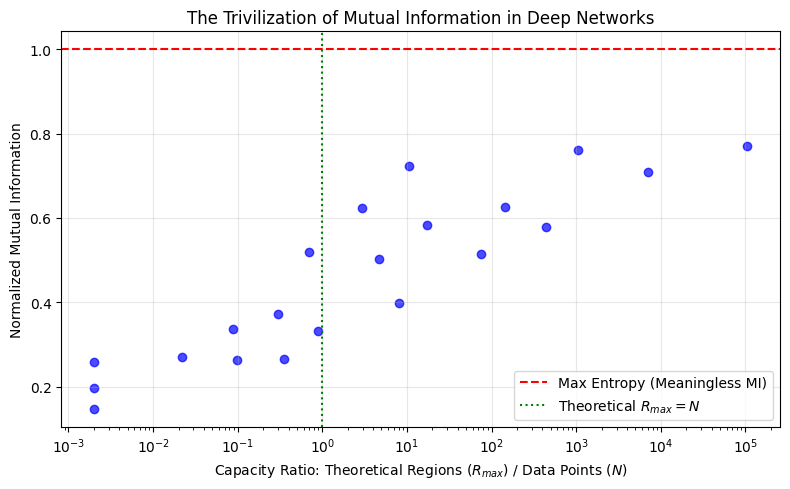

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import math

def calc_R_uniform(n_0, w, L):
    """Simplified Montúfar lower bound for uniform width 'w' and depth 'L'."""
    if w < n_0:
        return 0
    product_part = (w // n_0)**(n_0 * (L - 1))
    sum_part = sum(math.comb(w, j) for j in range(n_0 + 1))
    return product_part * sum_part

class DeepReLU(nn.Module):
    def __init__(self, n_0, w, L):
        super().__init__()
        layers = []
        in_dim = n_0
        for _ in range(L):
            layers.append(nn.Linear(in_dim, w))
            layers.append(nn.ReLU())
            in_dim = w
        self.network = nn.Sequential(*layers)

def get_normalized_mi_deep(X, model):
    """
    Calculates Normalized MI using the joint activation pattern of ALL hidden layers.
    """
    with torch.no_grad():
        activations = []
        out = X
        for layer in model.network:
            if isinstance(layer, nn.Linear):
                out = layer(out)
            elif isinstance(layer, nn.ReLU):
                # Binarize before ReLU sets negative values to exactly 0
                T = (out > 0).int()
                activations.append(T)
                out = layer(out)
                
        # Concatenate states of all layers into one massive binary pattern per data point
        full_pattern = torch.cat(activations, dim=1)
        
    # Fast GPU-based unique counting
    unique_patterns, counts = torch.unique(full_pattern, dim=0, return_counts=True)
    empirical_regions = unique_patterns.shape[0]
    
    probabilities = counts.float() / counts.sum()
    H_T = -torch.sum(probabilities * torch.log2(probabilities)).item()
    
    H_X = np.log2(X.shape[0])
    normalized_mi = H_T / H_X if H_X > 0 else 0.0
    
    return normalized_mi, empirical_regions

def run_deep_capacity_experiment():
    N = 2000          # Fixed dataset size
    n_0 = 2           # 2D input space
    X = torch.randn(N, n_0)
    
    widths = [2, 4, 6, 8, 10, 15, 20]
    depths = [2, 3, 4]
    
    results_capacity_ratio = []
    results_mi = []
    
    print(f"Running deep experiment for N={N} points...")
    
    for L in depths:
        for w in widths:
            R_max = calc_R_uniform(n_0, w, L)
            if R_max == 0: continue
                
            model = DeepReLU(n_0, w, L)
            norm_mi, emp_regions = get_normalized_mi_deep(X, model)
            
            # We track the ratio: Theoretical Maximum Regions / Dataset Size
            capacity_ratio = R_max / N
            
            results_capacity_ratio.append(capacity_ratio)
            results_mi.append(norm_mi)
            
            print(f"L={L}, w={w} | R_max={R_max} | Emp Regions={emp_regions} | MI={norm_mi:.3f}")

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.scatter(results_capacity_ratio, results_mi, color='blue', alpha=0.7)
    plt.axhline(y=1.0, color='red', linestyle='--', label='Max Entropy (Meaningless MI)')
    plt.axvline(x=1.0, color='green', linestyle=':', label='Theoretical $R_{max} = N$')
    
    plt.xscale('log')
    plt.xlabel('Capacity Ratio: Theoretical Regions ($R_{max}$) / Data Points ($N$)')
    plt.ylabel('Normalized Mutual Information')
    plt.title('The Trivilization of Mutual Information in Deep Networks')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_deep_capacity_experiment()

Running Grid Search for Deep Network (L=5, n_0=10)...


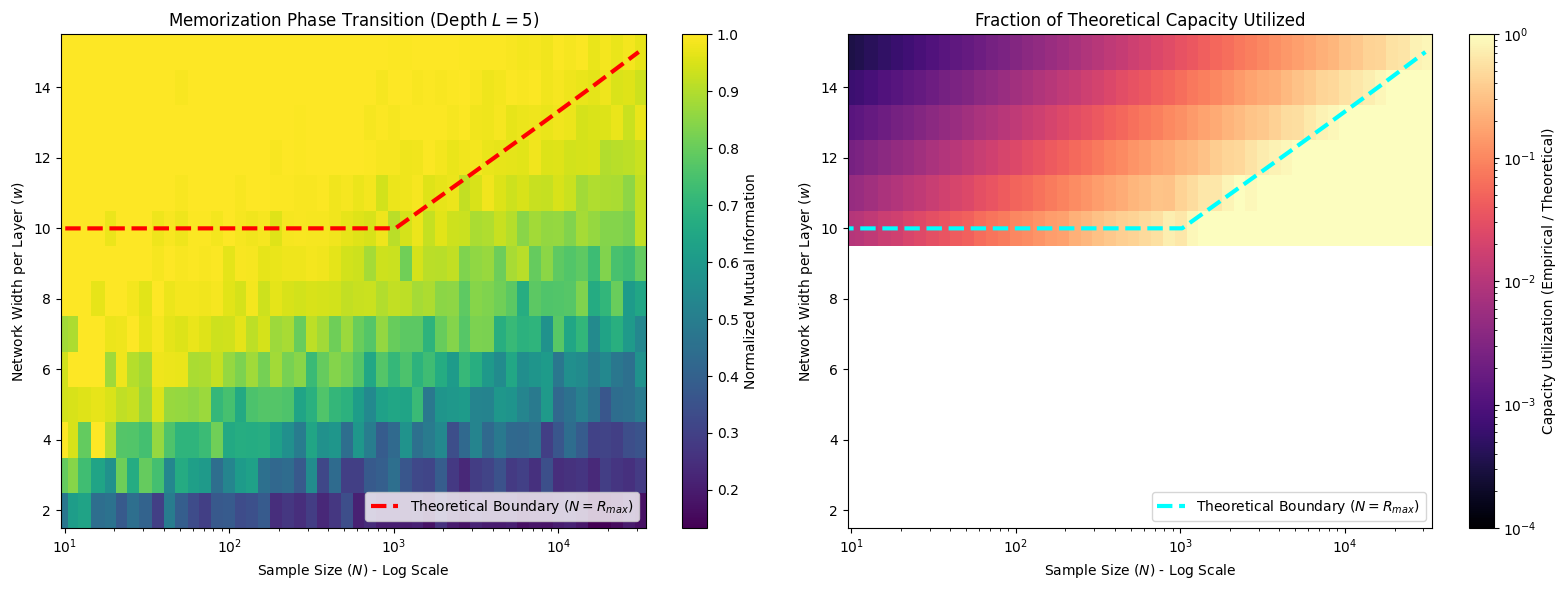

In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.colors import LogNorm

def calc_R_uniform(n_0, w, L):
    """Calculates the theoretical lower bound of maximum linear regions."""
    if w < n_0:
        return 0
    product_part = (w // n_0)**(n_0 * (L - 1))
    sum_part = sum(math.comb(w, j) for j in range(n_0 + 1))
    return product_part * sum_part

class DeepReLU(nn.Module):
    """A standard Deep ReLU network with uniform hidden layer width."""
    def __init__(self, n_0, w, L):
        super().__init__()
        layers = []
        in_dim = n_0
        for _ in range(L):
            layers.append(nn.Linear(in_dim, w))
            layers.append(nn.ReLU())
            in_dim = w
        self.network = nn.Sequential(*layers)

def get_deep_metrics(X, model):
    """
    Extracts the joint activation pattern across all hidden layers.
    Returns Normalized MI and the raw number of empirical linear regions.
    """
    with torch.no_grad():
        activations = []
        out = X
        for layer in model.network:
            if isinstance(layer, nn.Linear):
                out = layer(out)
            elif isinstance(layer, nn.ReLU):
                T = (out > 0).int()
                activations.append(T)
                out = layer(out)
                
        # The true deep activation pattern is the concatenation of all layers
        full_pattern = torch.cat(activations, dim=1)
        
    unique_patterns, counts = torch.unique(full_pattern, dim=0, return_counts=True)
    empirical_regions = unique_patterns.shape[0]
    
    probabilities = counts.float() / counts.sum()
    H_T = -torch.sum(probabilities * torch.log2(probabilities)).item()
    
    H_X = np.log2(X.shape[0])
    normalized_mi = H_T / H_X if H_X > 0 else 0.0
    
    return normalized_mi, empirical_regions

def run_deep_heatmap_experiment():
    n_0 = 10    # Fixed input dimension
    L = 5      # Fixed network depth (3 hidden layers)
    
    # Define grid parameters
    # We use a logarithmic scale for N because theoretical capacity grows exponentially
    N_values = np.logspace(1, 4.5, 50, dtype=int)  # From N=10 to ~31,000
    w_values = np.arange(2, 16, 1)                 # Width from 2 to 12
    
    mi_matrix = np.zeros((len(w_values), len(N_values)))
    utilization_matrix = np.zeros((len(w_values), len(N_values)))
    
    print(f"Running Grid Search for Deep Network (L={L}, n_0={n_0})...")
    
    for i, w in enumerate(w_values):
        # Calculate theoretical maximum regions for this width
        R_max = calc_R_uniform(n_0, w, L)
        
        for j, N in enumerate(N_values):
            X = torch.randn(N, n_0)
            model = DeepReLU(n_0, w, L)
            
            norm_mi, emp_regions = get_deep_metrics(X, model)
            
            mi_matrix[i, j] = norm_mi
            
            # Calculate utilization: What % of theoretical capacity did we actually use?
            # We cap it at 1.0 just in case N < R_max and it uses a tiny fraction perfectly
            utilization = min(emp_regions / R_max, 1.0) if R_max > 0 else 0
            utilization_matrix[i, j] = utilization

    # --- Plotting ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    X_mesh, Y_mesh = np.meshgrid(N_values, w_values)
    
    # Calculate the theoretical cliff line: N = R_max(w)
    theoretical_cliff_N = [calc_R_uniform(n_0, w, L) for w in w_values]

    # Subplot 1: Normalized MI Heatmap
    ax1 = axes[0]
    cp1 = ax1.pcolormesh(X_mesh, Y_mesh, mi_matrix, shading='auto', cmap='viridis')
    fig.colorbar(cp1, ax=ax1, label='Normalized Mutual Information')
    
    # Plot the theoretical cliff line
    valid_idx = np.array(theoretical_cliff_N) <= max(N_values)
    ax1.plot(np.array(theoretical_cliff_N)[valid_idx], w_values[valid_idx], 
             color='red', linestyle='--', linewidth=3, 
             label='Theoretical Boundary ($N = R_{max}$)')
    
    ax1.set_xscale('log')
    ax1.set_title(f"Memorization Phase Transition (Depth $L={L}$)")
    ax1.set_xlabel("Sample Size ($N$) - Log Scale")
    ax1.set_ylabel("Network Width per Layer ($w$)")
    ax1.legend(loc='lower right')

    # Subplot 2: Capacity Utilization Heatmap
    ax2 = axes[1]
    # We use LogNorm for coloring because utilization drops exponentially fast
    cp2 = ax2.pcolormesh(X_mesh, Y_mesh, utilization_matrix, shading='auto', 
                         cmap='magma', norm=LogNorm(vmin=1e-4, vmax=1.0))
    fig.colorbar(cp2, ax=ax2, label='Capacity Utilization (Empirical / Theoretical)')
    
    ax2.plot(np.array(theoretical_cliff_N)[valid_idx], w_values[valid_idx], 
             color='cyan', linestyle='--', linewidth=3, 
             label='Theoretical Boundary ($N = R_{max}$)')
    
    ax2.set_xscale('log')
    ax2.set_title("Fraction of Theoretical Capacity Utilized")
    ax2.set_xlabel("Sample Size ($N$) - Log Scale")
    ax2.set_ylabel("Network Width per Layer ($w$)")
    ax2.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_deep_heatmap_experiment()

In [2]:
from geobin_py import Region, Tree
from src_experiment.paths import outputs

In [3]:
tree = Tree(outputs / "wbc_nr_regions/dim3_[7, 7, 7]_lr0.01/seed_102.h5", 0)

  - Loading Epoch 0...


In [ ]:
# for region in tree.get_regions_at_layer(1):
#     print(f"Vol ex: {region.volume_ex}          Vol es: {region.volume_es}")

Vol ex: 1.2749966873301313e-06          Vol es: 1.5378177421578622e-08
Vol ex: inf          Vol es: 0.029096685763426507
Vol ex: 7.181334923769436e-08          Vol es: -1.0
Vol ex: inf          Vol es: -1.0
Vol ex: 3.522567440861184e-07          Vol es: -1.0
Vol ex: 6.772307147580907e-08          Vol es: 1.1874130184330826e-08
Vol ex: 2.5734882182450076e-10          Vol es: -1.0
Vol ex: inf          Vol es: -1.0
Vol ex: 6.1943723395543226e-12          Vol es: -1.0
Vol ex: inf          Vol es: 0.05822877034492611
Vol ex: 6.310649962357501e-08          Vol es: 1.1838483854143117e-08
Vol ex: 2.810216849643769e-05          Vol es: 1.3385413472458201e-05
Vol ex: inf          Vol es: 0.3065013347652094
Vol ex: inf          Vol es: 0.08685986371389584
Vol ex: inf          Vol es: -1.0
Vol ex: 9.345489073392689e-08          Vol es: -1.0
Vol ex: 1.5799491710228642e-07          Vol es: 5.6546122877852855e-11
Vol ex: 8.83805627066176e-09          Vol es: -1.0
Vol ex: 2.9361677234915176e-08       

In [36]:
from src_experiment import get_new_data

In [37]:
x, y = get_new_data("composite")

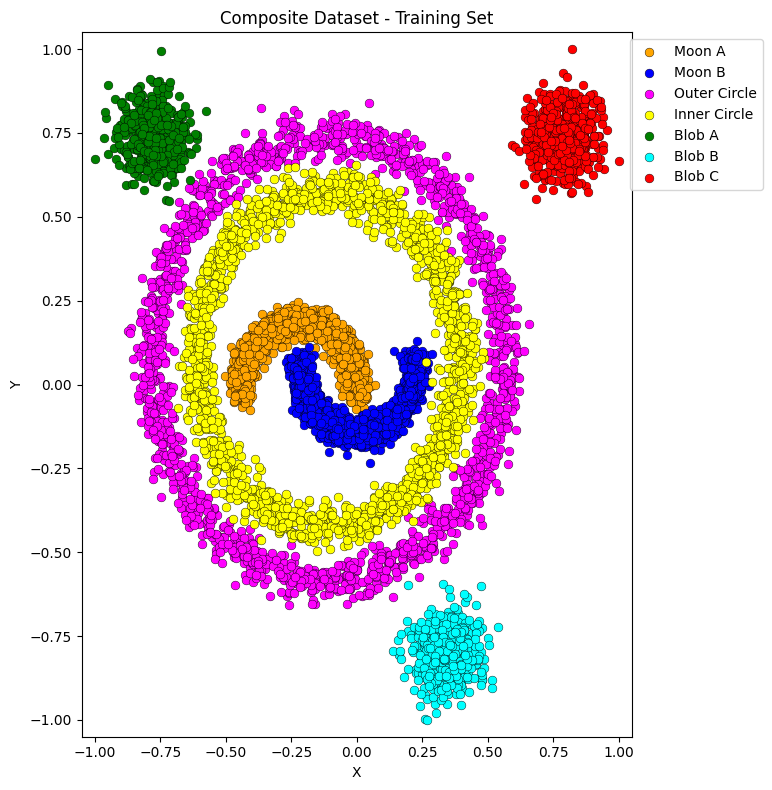

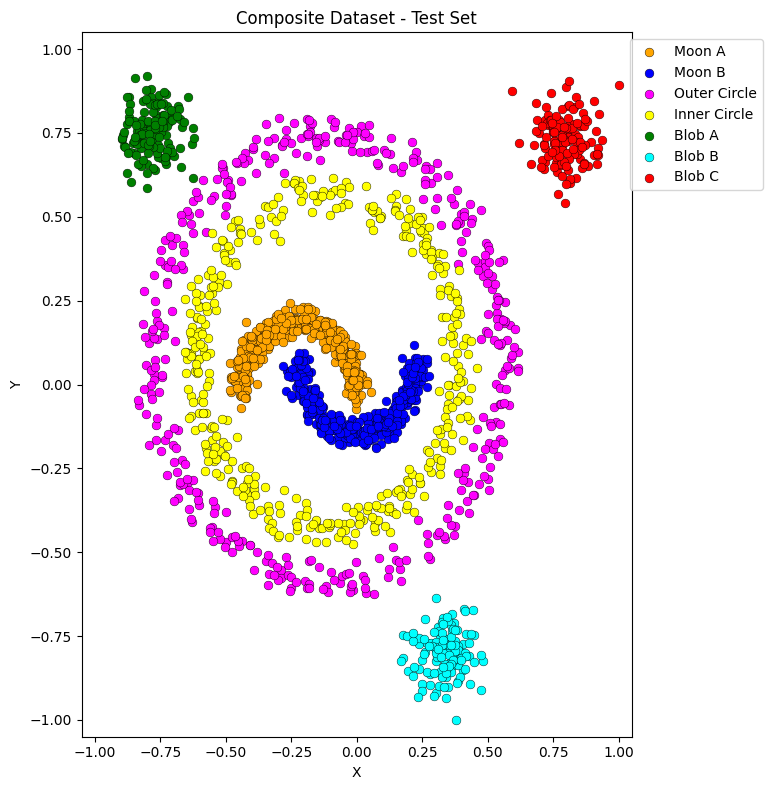

In [38]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_dataloader(dataloader, title="DataLoader Contents"):
    """Extracts all batches from a PyTorch DataLoader and plots them."""
    all_x = []
    all_y = []
    
    # 1. Extract data from all batches
    for batch_x, batch_y in dataloader:
        all_x.append(batch_x.numpy())
        all_y.append(batch_y.numpy())
        
    # 2. Recombine into single arrays
    X = np.concatenate(all_x, axis=0)
    y = np.concatenate(all_y, axis=0)
    
    # 3. Plotting setup
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Using your original colors and labels
    colours = ["orange", "blue", "magenta", "yellow", "green", "cyan", "red"]
    label_names = ["Moon A", "Moon B", "Outer Circle", "Inner Circle", "Blob A", "Blob B", "Blob C"]
    
    # 4. Scatter plot
    unique_labels = np.sort(np.unique(y))
    for label in unique_labels:
        ax.scatter(X[y==label, 0], X[y==label, 1], 
                   c=colours[label], s=40, label=label_names[label],
                   edgecolors='black', linewidth=0.3)
                   
    # Show the strict bounding box boundaries (with a tiny buffer to see the edges)
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    
    ax.set(xlabel='X',
           ylabel='Y',
           title=title)
           
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
    plt.tight_layout()
    plt.show()

# --- How to use it ---
# 1. Unpack the dataloaders correctly
train_loader, test_loader = get_new_data("composite", batch_size=128)

# 2. Plot the training set
plot_dataloader(train_loader, title="Composite Dataset - Training Set")

# 3. Plot the testing set
plot_dataloader(test_loader, title="Composite Dataset - Test Set")